# 1 — The signal, and what the sensor actually gives you

Before any modelling, two things about this dataset decide how everything else
has to be built. Both are invisible if you trust the file's shape.

*Figures here are aggregates or relative-time windows. No plot in this
repository carries a real date — see the README for why.*

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import figures
from load import load_clean

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
data = load_clean()
len(data)

28579

## The 1-minute resolution is not real

The export has one row per minute. It is padded: the device reports every few
minutes and the app repeats the last value in between. Measuring a derivative
on that grid measures the padding.

In [2]:
from load import load_raw
r = load_raw().set_index("ts")["co2"]
repeated = (r.diff() == 0).mean()
changes = r[r.diff() != 0]
gaps = changes.index.to_series().diff().dt.total_seconds().div(60)
gaps = gaps[gaps < 600]

print(f"consecutive readings that are byte-identical : {repeated:.1%}")
print(f"median minutes between real changes          : {gaps.median():.0f}")
print(f"so the honest resolution is roughly           : {gaps.median():.0f} min, not 1")

consecutive readings that are byte-identical : 88.5%
median minutes between real changes          : 8
so the honest resolution is roughly           : 8 min, not 1


So everything is resampled to 5 minutes. On the raw grid the implied rates of
change reach several hundred ppm per minute, which is quantisation, not air.

In [3]:
per_min = r.diff().abs()
print("implied |ΔCO2| per minute on the raw grid:")
print(f"  99th percentile {np.percentile(per_min.dropna(), 99):.0f} ppm   max {per_min.max():.0f} ppm")
print(f"\nafter resampling to 5 min, |dC/dt| p99: "
      f"{np.nanpercentile((data.co2.diff() / (5/60)).abs(), 99):.0f} ppm/h")

implied |ΔCO2| per minute on the raw grid:
  99th percentile 82 ppm   max 1151 ppm

after resampling to 5 min, |dC/dt| p99: 1692 ppm/h


## Three channels, not six

The file ships absolute humidity, dew point and vapour pressure deficit next to
temperature and relative humidity. They are not measurements — they are the
Magnus equation applied to the other two. Feeding all six to a model injects
the same information three times.

In [4]:
d = load_clean(keep_derived=True)
es = 0.61094 * np.exp(17.625 * d.temp / (d.temp + 243.04))
predicted = 2.16679 * (es * d.rh / 100 * 1000) / (d.temp + 273.15)

print(f"absolute humidity reproduced from (temp, rh):")
print(f"  correlation      r = {np.corrcoef(predicted, d.abs_hum)[0,1]:.6f}")
print(f"  mean abs. error    = {(predicted - d.abs_hum).abs().mean():.3f} g/m³")

absolute humidity reproduced from (temp, rh):
  correlation      r = 0.999994
  mean abs. error    = 0.018 g/m³


## What presence looks like

Aggregated over five months, the daily profile is a routine: a trough in the
small hours, a working-hours rise, an afternoon dip, an evening climb.

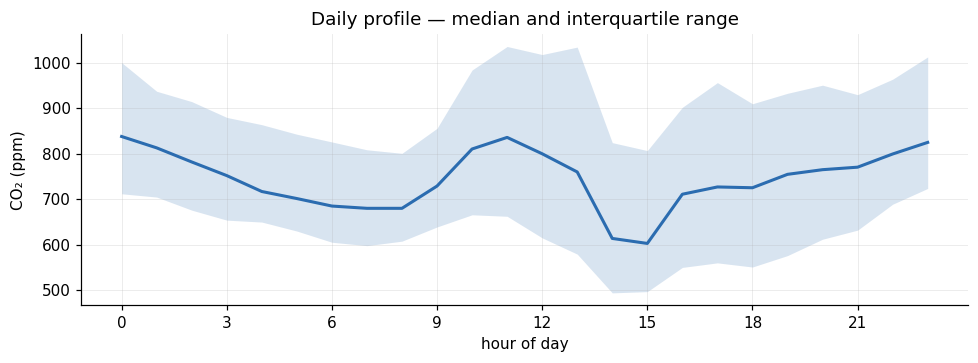

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.4))
figures.hour_profile(data.co2, "CO₂ (ppm)", "Daily profile — median and interquartile range", ax=ax)
plt.tight_layout(); plt.show()

And a representative week, plotted against elapsed hours rather than dates.
The sawtooth is the point: sharp rises when the room fills, long exponential
decays when it empties. Those decays are what the ventilation estimate is
built from.

Which week is drawn is chosen at random and is not recorded. A fixed selector
would be an index into the series: anyone who learned the start date could
invert it and put a date on every peak here.

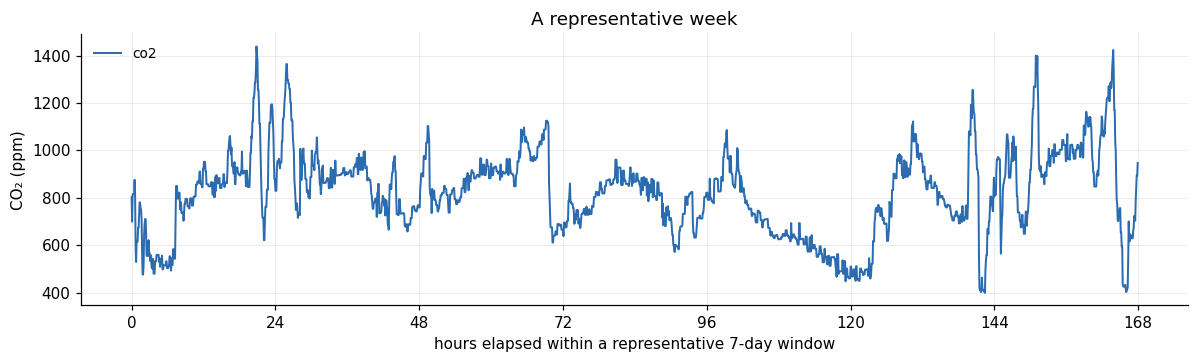

In [6]:
fig, ax = plt.subplots(figsize=(11, 3.4))
figures.relative_window(data, ["co2"], days=7,
                        title="A representative week", ylabel="CO₂ (ppm)", ax=ax)
plt.tight_layout(); plt.show()